<a href="https://colab.research.google.com/github/Qunzh/CAN_GridCell_Model/blob/main/Ring_Model_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [139]:
# Ring Model

def ring_model(epsilon, theta_cue, A, c, n_number, tau, J_0, J_2, dt, total_t, theta_0, a):

  # Parameters for thalamic(LGN) input: epsilon = tuning, theta_cue = peak preferred orientation, c = contrast, A = amplitude
  # Parameters for V1: n_number = total number of neurons, tau = time constant, J_0 = recurrent inhibition weight, J_2 = recurrent excitation weight
  # Parameters for time: dt = length of timestep, total_t = total integration time
  # Parameters for initial conditions: theta_0 = initial tuned orientation of V1, a = initial rate amplitude of V1

  # Initialization of Data Matrix
  t_steps = int(total_t/dt)
  rate = np.zeros((t_steps,n_number)) #rate time course for all neurons
  I_theta = np.zeros((t_steps,n_number)) #Input for all neurons
  recurrent = np.zeros((t_steps,n_number)) #recurrent input for all neurons
  h_theta = np.zeros((n_number)) #thalamic input for all neurons

  # Neuron Initial Condition
  theta_i = np.zeros((n_number)) #orientation tuning for all neurons
  for i in range(0,n_number):
    theta_i[i] = (np.pi/n_number) * i - np.pi/2
    a = 2 #initial rate amplitude
    theta_0 = 0 #initial tuned orientation
    rate[0,i] = a*np.cos(2*(theta_i[i]-theta_0))

  # V1 Orientation tuning steady state calculation
  for i in range(0,n_number):
    h_theta[i] = A*c*(1-epsilon+epsilon*np.cos(2*(theta_i[i]-theta_cue)))
  for t in range(0,t_steps):
    for i in range(0,n_number):
      for n in range(0,n_number):
        recurrent_i = (J_0 + J_2 * np.cos(2*(theta_i[i]-theta_i[n])))*rate[t-1,n]
        recurrent[t,i] = recurrent[t,i] + recurrent_i*(np.pi/n_number)
      I_theta[t,i] = h_theta[i] + recurrent[t,i]
      if I_theta[t,i] < 0:
        I_theta[t,i] = 0
      drdt = (-rate[t-1,i]+I_theta[t,i])/tau
      rate[t,i] = rate[t-1,i] + drdt*dt

  steady_state = rate[t,:]
  return theta_i, steady_state

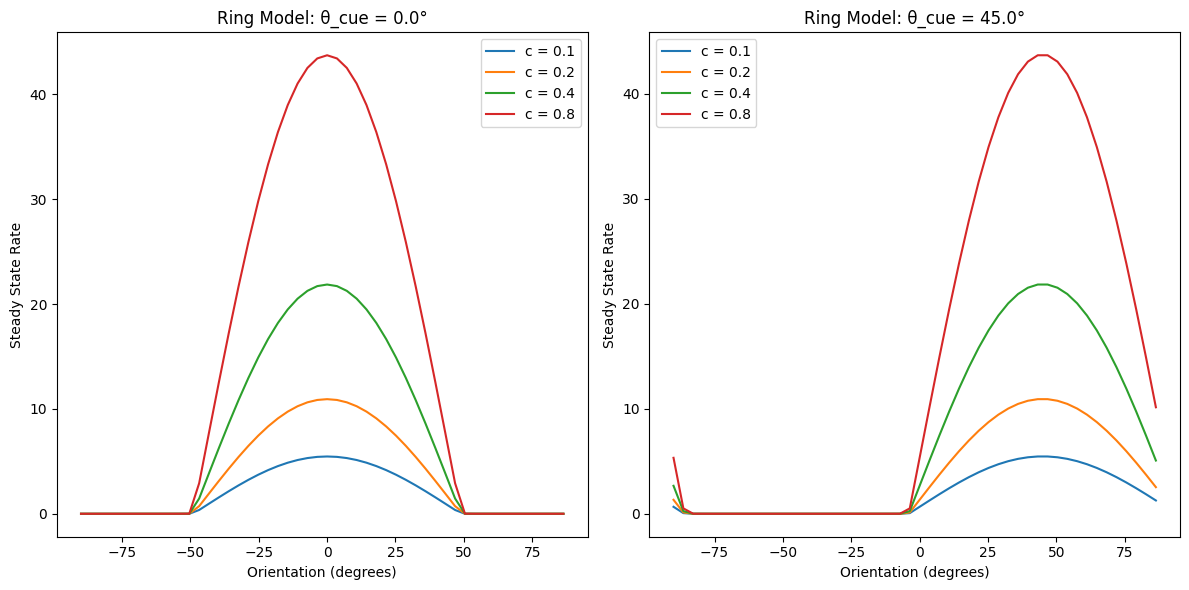

In [147]:
# Define multiple contrast values
contrast_values = [0.1, 0.2, 0.4, 0.8]

# Define theta_cue values
theta_cue_values = [0, np.pi/4]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for idx, theta_cue in enumerate(theta_cue_values):
    ax = axes[idx]
    for c in contrast_values:
        theta_i, steady_state = ring_model(0.1, theta_cue, 40, c, 50, 10, -0.5, 1, 0.1, 100, np.pi/4, 2)
        ax.plot(np.rad2deg(theta_i), steady_state, label=f'c = {c}')

    ax.set_xlabel('Orientation (degrees)')
    ax.set_ylabel('Steady State Rate')
    ax.set_title(f'Ring Model: θ_cue = {np.rad2deg(theta_cue):.1f}°')
    ax.legend()

plt.tight_layout()
plt.show()

In [103]:
print(np.array([0.1,0.2,0.4,0.8]))

[0.1 0.2 0.4 0.8]


In [71]:
print(recurrent[0:3,:])

[[ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [-6.28318531 -3.11682026 -3.04289374 -2.92097898 -2.75299863 -2.54160185
  -2.29012248 -2.00252652 -1.68334952 -1.33762509 -0.97080552 -0.58867576
  -0.19726223  0.19726223  0.58867576  0.97080552  1.33762509  1.68334952
   2.00252652  2.29012248  2.54160185  2.75299863  2.92097898  3.04289374
   3.11682026  3.14159265  3.11682026  3.04289374  2.92097898  2.75299863
   2.54160185  2.29012248  2.00252652  1.68334952  1.33762509  0.97080552
 

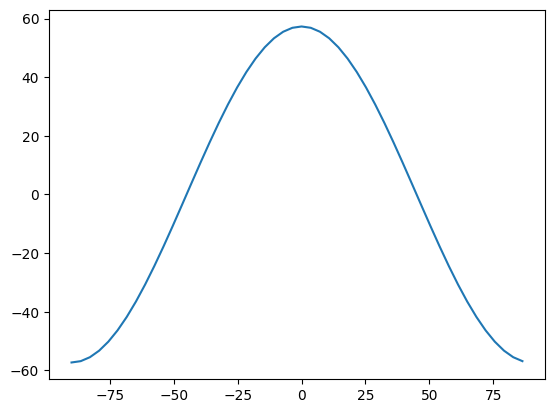

In [24]:
plt.plot(np.rad2deg(theta_i),np.rad2deg(np.cos(2*(theta_i[25]-theta_i))))

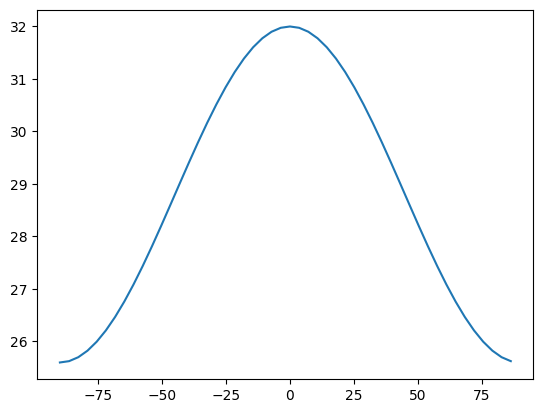

In [32]:
plt.plot(np.rad2deg(theta_i),h_theta)

In [77]:
print(np.linspace(0,total_t))

[  0.           2.04081633   4.08163265   6.12244898   8.16326531
  10.20408163  12.24489796  14.28571429  16.32653061  18.36734694
  20.40816327  22.44897959  24.48979592  26.53061224  28.57142857
  30.6122449   32.65306122  34.69387755  36.73469388  38.7755102
  40.81632653  42.85714286  44.89795918  46.93877551  48.97959184
  51.02040816  53.06122449  55.10204082  57.14285714  59.18367347
  61.2244898   63.26530612  65.30612245  67.34693878  69.3877551
  71.42857143  73.46938776  75.51020408  77.55102041  79.59183673
  81.63265306  83.67346939  85.71428571  87.75510204  89.79591837
  91.83673469  93.87755102  95.91836735  97.95918367 100.        ]
